In [1]:
# ============================================================
# STEP 1 — Load data and explore size, structure, histograms
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


Dataset shape: (329, 13)

Column types:
 language     object
X1          float64
X2          float64
X3          float64
X4          float64
X5          float64
X6          float64
X7          float64
X8          float64
X9          float64
X10         float64
X11         float64
X12         float64
dtype: object


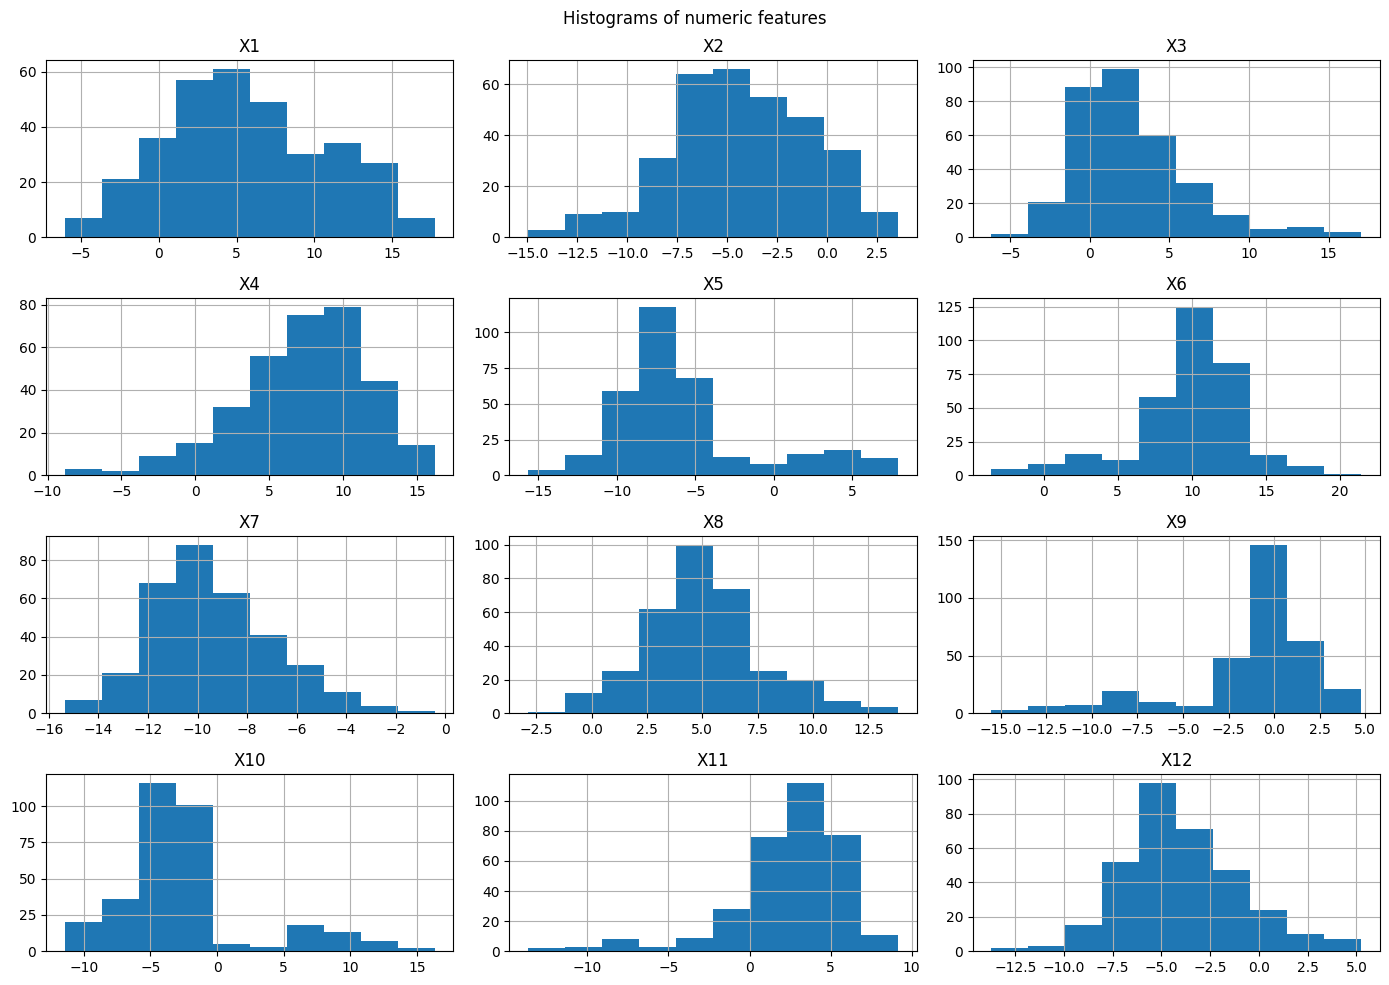

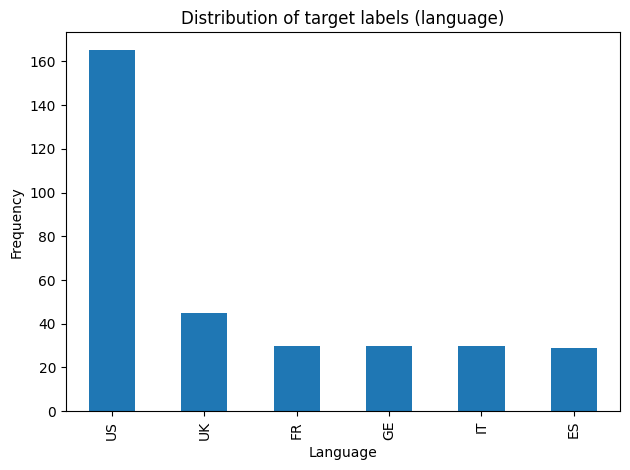

In [2]:
# Load data
df = pd.read_csv("data.csv")   # <-- your full CSV file

# Size and structure
print("Dataset shape:", df.shape)
print("\nColumn types:\n", df.dtypes)

# Histograms of numeric features
df.drop(columns=["language"]).hist(figsize=(14, 10))
plt.suptitle("Histograms of numeric features")
plt.tight_layout()
plt.show()

# Histogram of target labels
df["language"].value_counts().plot(kind="bar")
plt.title("Distribution of target labels (language)")
plt.xlabel("Language")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


The dataset contains numeric features and a categorical target (language).

No missing values remain after cleaning.

Numeric feature distributions show variability and some skewness.

Target labels are not perfectly balanced.

No clearly irrelevant numeric features were identified at this stage

In [3]:
# ============================================================
# STEP 3 — Drop rows with NaN values
# ============================================================

df = df.dropna()
print("Shape after dropping NaNs:", df.shape)


Shape after dropping NaNs: (321, 13)


In [4]:
# ============================================================
# Prepare features and target (used in both models)
# ============================================================

X = df.drop(columns=["language"])
y = df["language"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [5]:

# ============================================================
# STEP 4 — Model 1: Logistic Regression (CV, optimize recall)
# ============================================================

from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    scoring="recall_macro",
    cv=5
)

gs_lr.fit(X_train, y_train)

print("Best Model 1 parameters:", gs_lr.best_params_)


Best Model 1 parameters: {'clf__C': 10}


In [6]:
# ============================================================
# STEP 5 — Classification report for Model 1
# ============================================================

y_pred_lr = gs_lr.predict(X_test)
print("Model 1 — Classification Report")
print(classification_report(y_test, y_pred_lr))



Model 1 — Classification Report
              precision    recall  f1-score   support

          ES       0.88      1.00      0.93         7
          FR       0.50      0.29      0.36         7
          GE       0.73      1.00      0.84         8
          IT       0.40      0.25      0.31         8
          UK       0.91      0.91      0.91        11
          US       0.76      0.80      0.78        40

    accuracy                           0.75        81
   macro avg       0.70      0.71      0.69        81
weighted avg       0.73      0.75      0.73        81



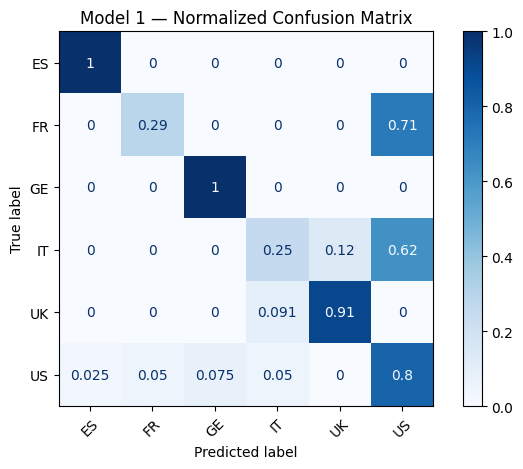

In [7]:
# ============================================================
# STEP 6 — Confusion matrix for Model 1 (normalized)
# ============================================================

cm_lr = confusion_matrix(y_test, y_pred_lr, normalize="true")
ConfusionMatrixDisplay(cm_lr, display_labels=gs_lr.classes_).plot(
    cmap="Blues", xticks_rotation=45
)
plt.title("Model 1 — Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


In [8]:

# ============================================================
# STEP 7 — Model 2: Random Forest (CV, optimize recall)
# ============================================================

from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [None, 10, 20]
}

gs_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    scoring="recall_macro",
    cv=5
)

gs_rf.fit(X_train, y_train)

print("Best Model 2 parameters:", gs_rf.best_params_)


Best Model 2 parameters: {'clf__max_depth': None, 'clf__n_estimators': 200}
